## ⚙️ **Libraries Import**

In [52]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
# from torchsummary import summary
from torch.utils.data import TensorDataset, DataLoader

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

PyTorch version: 2.8.0
Device: cpu


## ⏳ **Data Loading**

In [53]:
import pickle
FILE_PATH = "data/"

with open(FILE_PATH+"encoded_crawled_user2user_blocking_X.pkl", 'rb') as f:
    training_X_non_blocking = pickle.load(f)
with open(FILE_PATH+"encoded_crawled_user2user_blocking_Y.pkl", 'rb') as f:
    training_Y_non_blocking = pickle.load(f)
with open(FILE_PATH+"encoded_crawled_user2user_non_blocking_X.pkl", 'rb') as f:
    training_X_blocking = pickle.load(f)
with open(FILE_PATH+"encoded_crawled_user2user_non_blocking_Y.pkl", 'rb') as f:
    training_Y_blocking = pickle.load(f)

print(training_X_non_blocking[0])
print(training_X_blocking)

[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
[[[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [54]:
#BLOCKS
num_of_emptyInteractions = sum(1 for arr in training_X_blocking if len(arr)==0)
nonEmptyInteractions = list()
for l in training_X_blocking:
    if len(l)!=0:
        nonEmptyInteractions.append(l)
avgNum_of_interactions = sum(len(arr) for arr in nonEmptyInteractions)/len(nonEmptyInteractions)
print("the number of empty interactions are : " + str(num_of_emptyInteractions))
print("the total number of interactions are : " + str(len(training_X_blocking)) )
print("the average of interaction of the remaining interactions are: " + str(avgNum_of_interactions))
#NO BLOCKS
avgNum_of_interactions = sum(len(arr) for arr in training_X_non_blocking)/len(training_X_non_blocking)
print("the average of interaction of the non blocking interactions are: " + str(avgNum_of_interactions))

the number of empty interactions are : 0
the total number of interactions are : 460
the average of interaction of the remaining interactions are: 4.2956521739130435
the average of interaction of the non blocking interactions are: 2.1977777777777776


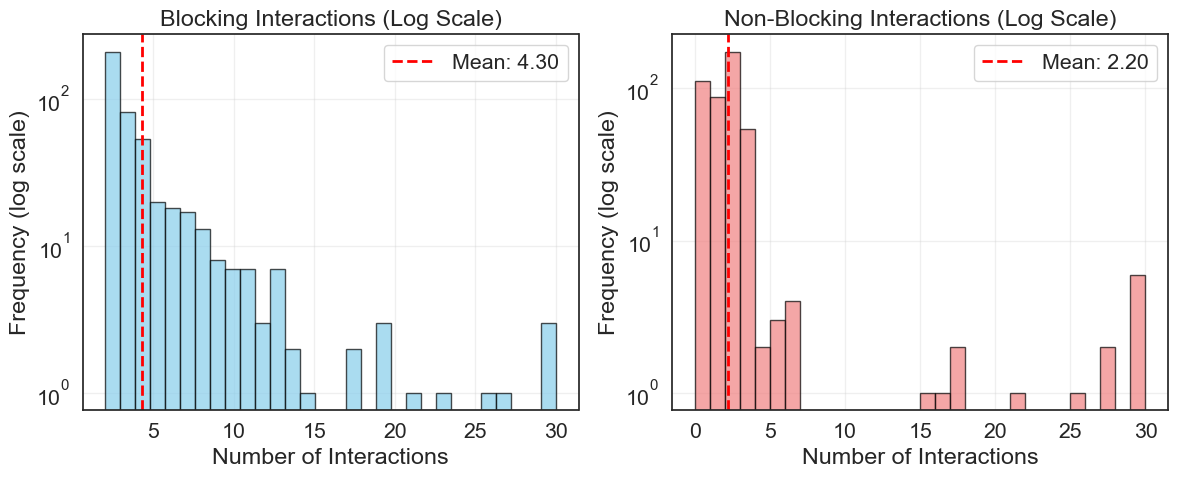

In [55]:
# Calculate lengths
blocking_lengths = [len(arr) for arr in nonEmptyInteractions]
non_blocking_lengths = [len(arr) for arr in training_X_non_blocking]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Blocking histogram (log scale)
axes[0].hist(blocking_lengths, bins=30, alpha=0.7, color='skyblue', edgecolor='black', log=True)
axes[0].axvline(np.mean(blocking_lengths), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {np.mean(blocking_lengths):.2f}')
axes[0].set_xlabel('Number of Interactions')
axes[0].set_ylabel('Frequency (log scale)')
axes[0].set_title('Blocking Interactions (Log Scale)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Non-blocking histogram (log scale)
axes[1].hist(non_blocking_lengths, bins=30, alpha=0.7, color='lightcoral', edgecolor='black', log=True)
axes[1].axvline(np.mean(non_blocking_lengths), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {np.mean(non_blocking_lengths):.2f}')
axes[1].set_xlabel('Number of Interactions')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].set_title('Non-Blocking Interactions (Log Scale)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## **Merging the two datasets and shuffling them**

In [56]:
SEED = 42

In [57]:
training_X = training_X_blocking + training_X_non_blocking
training_Y = training_Y_blocking + training_Y_non_blocking

In [58]:
import random

def shuffle_two_arrays_together(array1, array2, seed):
    """
    Shuffle two arrays while maintaining the same shuffling order.
    
    Args:
        array1: First array to shuffle
        array2: Second array to shuffle
        
    Returns:
        Tuple of (shuffled_array1, shuffled_array2)
    """
    if seed is not None:
        random.seed(seed)

    # Check if arrays have the same length
    if len(array1) != len(array2):
        raise ValueError("Arrays must have the same length")
    
    # Create a list of indices: [0, 1, 2, ..., n-1]
    indices = list(range(len(array1)))
    
    # Shuffle the indices using Fisher-Yates algorithm
    random.shuffle(indices)
    
    # Use the shuffled indices to reorder both arrays
    shuffled1 = [array1[i] for i in indices]
    shuffled2 = [array2[i] for i in indices]
    
    return shuffled1, shuffled2

In [59]:
training_X, training_Y = shuffle_two_arrays_together(training_X, training_Y, SEED)

## 🔎 **Creating DataFrames from encoding**

In [60]:
n_users = len(training_X)

unique_users = [i for i in range(n_users)]

print(len(unique_users))
print(unique_users[:10])

910
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [61]:
import pandas as pd

temp_df = pd.DataFrame()

#training
for user in unique_users:
    interaction = training_X[user]
    temp = pd.DataFrame(interaction)
    temp.insert(0, 'userID', user)  # Insert ID column at position 0
    temp_df = pd.concat([temp_df, temp], ignore_index=True)

label_mapping = {
    (0,0) : 0,
    (1,0) : 1, #blockAB
    (0,1) : 2, #blockBA
    (1,1) : 3
}

label_df = pd.DataFrame()
#labels
for user in unique_users:
    interaction = training_Y[user]
    #interaction_tuple = tuple(interaction)
    #mapped_label = label_mapping.get(interaction_tuple, -1)
    #temp = pd.DataFrame({'userID': [user], 'label': [mapped_label]})
    temp = pd.DataFrame({'userID': [user], 'label': [interaction]})
    label_df = pd.concat([label_df, temp], ignore_index=True)


print(temp_df.head())
print(label_df.head())

print(temp_df.shape)
print(label_df.shape)

training_df = pd.merge(temp_df, label_df, on='userID', how='inner')

print(training_df.head())

   userID    0    1    2    3    4    5    6    7    8  ...   92   93   94  \
0       0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
1       0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
2       0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
3       1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
4       2  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   

    95   96   97   98   99  100  101  
0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
2  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
3  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

[5 rows x 103 columns]
   userID  label
0       0      0
1       1      1
2       2      1
3       3      1
4       4      1
(2965, 103)
(910, 2)
   userID    0    1    2    3    4    5    6    7    8  ...   93   94   95  \
0       0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0

## 🔄 **Data Preprocessing**

In [62]:
distinct_count = label_df['label'].value_counts()
print(f"Distinct values in column A: {distinct_count}")

Distinct values in column A: label
0    460
1    450
Name: count, dtype: int64


In [63]:
# Get unique user IDs and shuffle them
unique_users = training_df['userID'].unique()
random.seed(SEED) # Ensure reproducibility of shuffling
random.shuffle(unique_users)

test_users = unique_users

# Split the dataset into training, validation, and test sets based on user IDs
df_test = training_df[training_df['userID'].isin(test_users)]

# Print the shapes of the training, validation, and test sets
print(f'Training set shape: {df_test.shape}')


Training set shape: (2965, 104)


In [64]:
# Define the window size
WINDOW_SIZE = 200

# Define the stride for overlapping windows
STRIDE = 50

In [65]:
# Define a function to build sequences from the dataset
def build_sequences(df, window=200, stride=200):
    # Sanity check to ensure the window is divisible by the stride
    assert window % stride == 0

    # Initialise lists to store sequences and their corresponding labels
    dataset = []
    labels = []

    training_columns_needed = [i for i in range(0, 102)]
    label_columns_needed = ["label"]

    # Iterate over unique IDs in the DataFrame
    for id in df['userID'].unique():
        # Extract sensor data for the current ID
        temp = df[df['userID'] == id][training_columns_needed].values.astype(np.float32)

        # Retrieve the activity label for the current ID
        label = df[df['userID'] == id][label_columns_needed].values[0]

        # Calculate padding length to ensure full windows
        padding_len = window - len(temp) % window

        # Create zero padding and concatenate with the data
        padding = np.zeros((padding_len, len(training_columns_needed)), dtype='float32')
        temp = np.concatenate((temp, padding))

        # Build feature windows and associate them with labels
        idx = 0
        while idx + window <= len(temp):
            dataset.append(temp[idx:idx + window])
            labels.append(label[0])
            idx += stride

    # Convert lists to numpy arrays for further processing
    dataset = np.array(dataset)
    labels = np.array(labels)

    return dataset, labels

In [66]:
# Generate sequences and labels for the training set
X_test, y_test = build_sequences(df_test, WINDOW_SIZE, STRIDE)

In [67]:
# Define the input shape based on the training data
input_shape = X_test.shape[1:]

# Define the number of classes based on the categorical labels
num_classes = 4

In [68]:
print(np.unique(y_test))

[0 1]


In [69]:
# Convert numpy arrays to PyTorch datasets (pairs features with labels)
test_ds = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

In [70]:
# Define the batch size, which is the number of samples in each batch
BATCH_SIZE = 512

In [71]:
def make_loader(ds, batch_size, shuffle, drop_last):
    # Determine optimal number of worker processes for data loading
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    # Create DataLoader with performance optimizations
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,  # Faster GPU transfer
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,  # Load 4 batches ahead
    )

In [72]:
# Create data loaders with different settings for each phase
test_loader = make_loader(test_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

In [73]:
# Get one batch from the training data loader
for xb, yb in test_loader:
    print("Features batch shape:", xb.shape)
    print("Labels batch shape:", yb.shape)
    break # Stop after getting one batch

Features batch shape: torch.Size([512, 200, 102])
Labels batch shape: torch.Size([512])


## 🛠️ **Model Building**

In [74]:
def recurrent_summary(model, input_size):
    """
    Custom summary function that emulates torchinfo's output while correctly
    counting parameters for RNN/GRU/LSTM layers.

    This function is designed for models whose direct children are
    nn.Linear, nn.RNN, nn.GRU, or nn.LSTM layers.

    Args:
        model (nn.Module): The model to analyze.
        input_size (tuple): Shape of the input tensor (e.g., (seq_len, features)).
    """

    # Dictionary to store output shapes captured by forward hooks
    output_shapes = {}
    # List to track hook handles for later removal
    hooks = []

    def get_hook(name):
        """Factory function to create a forward hook for a specific module."""
        def hook(module, input, output):
            # Handle RNN layer outputs (returns a tuple)
            if isinstance(output, tuple):
                # output[0]: all hidden states with shape (batch, seq_len, hidden*directions)
                shape1 = list(output[0].shape)
                shape1[0] = -1  # Replace batch dimension with -1

                # output[1]: final hidden state h_n (or tuple (h_n, c_n) for LSTM)
                if isinstance(output[1], tuple):  # LSTM case: (h_n, c_n)
                    shape2 = list(output[1][0].shape)  # Extract h_n only
                else:  # RNN/GRU case: h_n only
                    shape2 = list(output[1].shape)

                # Replace batch dimension (middle position) with -1
                shape2[1] = -1

                output_shapes[name] = f"[{shape1}, {shape2}]"

            # Handle standard layer outputs (e.g., Linear)
            else:
                shape = list(output.shape)
                shape[0] = -1  # Replace batch dimension with -1
                output_shapes[name] = f"{shape}"
        return hook

    # 1. Determine the device where model parameters reside
    try:
        device = next(model.parameters()).device
    except StopIteration:
        device = torch.device("cpu")  # Fallback for models without parameters

    # 2. Create a dummy input tensor with batch_size=1
    dummy_input = torch.randn(1, *input_size).to(device)

    # 3. Register forward hooks on target layers
    # Iterate through direct children of the model (e.g., self.rnn, self.classifier)
    for name, module in model.named_children():
        if isinstance(module, (nn.Linear, nn.RNN, nn.GRU, nn.LSTM)):
            # Register the hook and store its handle for cleanup
            hook_handle = module.register_forward_hook(get_hook(name))
            hooks.append(hook_handle)

    # 4. Execute a dummy forward pass in evaluation mode
    model.eval()
    with torch.no_grad():
        try:
            model(dummy_input)
        except Exception as e:
            print(f"Error during dummy forward pass: {e}")
            # Clean up hooks even if an error occurs
            for h in hooks:
                h.remove()
            return

    # 5. Remove all registered hooks
    for h in hooks:
        h.remove()

    # --- 6. Print the summary table ---

    print("-" * 79)
    # Column headers
    print(f"{'Layer (type)':<25} {'Output Shape':<28} {'Param #':<18}")
    print("=" * 79)

    total_params = 0
    total_trainable_params = 0

    # Iterate through modules again to collect and display parameter information
    for name, module in model.named_children():
        if name in output_shapes:
            # Count total and trainable parameters for this module
            module_params = sum(p.numel() for p in module.parameters())
            trainable_params = sum(p.numel() for p in module.parameters() if p.requires_grad)

            total_params += module_params
            total_trainable_params += trainable_params

            # Format strings for display
            layer_name = f"{name} ({type(module).__name__})"
            output_shape_str = str(output_shapes[name])
            params_str = f"{trainable_params:,}"

            print(f"{layer_name:<25} {output_shape_str:<28} {params_str:<15}")

    print("=" * 79)
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {total_trainable_params:,}")
    print(f"Non-trainable params: {total_params - total_trainable_params:,}")
    print("-" * 79)

In [75]:
class RecurrentClassifier(nn.Module):
    """
    Generic RNN classifier (RNN, LSTM, GRU).
    Uses the last hidden state for classification.
    """
    def __init__(
            self,
            input_size,
            hidden_size,
            num_layers,
            num_classes,
            rnn_type='GRU',        # 'RNN', 'LSTM', or 'GRU'
            bidirectional=False,
            dropout_rate=0.2
            ):
        super().__init__()

        self.rnn_type = rnn_type
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional

        # Map string name to PyTorch RNN class
        rnn_map = {
            'RNN': nn.RNN,
            'LSTM': nn.LSTM,
            'GRU': nn.GRU
        }

        if rnn_type not in rnn_map:
            raise ValueError("rnn_type must be 'RNN', 'LSTM', or 'GRU'")

        rnn_module = rnn_map[rnn_type]

        # Dropout is only applied between layers (if num_layers > 1)
        dropout_val = dropout_rate if num_layers > 1 else 0

        # Create the recurrent layer
        self.rnn = rnn_module(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,       # Input shape: (batch, seq_len, features)
            bidirectional=bidirectional,
            dropout=dropout_val
        )

        # Calculate input size for the final classifier
        if self.bidirectional:
            classifier_input_size = hidden_size * 2 # Concat fwd + bwd
        else:
            classifier_input_size = hidden_size

        # Final classification layer
        self.classifier = nn.Linear(classifier_input_size, num_classes)

    def forward(self, x):
        """
        x shape: (batch_size, seq_length, input_size)
        """

        # rnn_out shape: (batch_size, seq_len, hidden_size * num_directions)
        rnn_out, hidden = self.rnn(x)

        # LSTM returns (h_n, c_n), we only need h_n
        if self.rnn_type == 'LSTM':
            hidden = hidden[0]

        # hidden shape: (num_layers * num_directions, batch_size, hidden_size)

        if self.bidirectional:
            # Reshape to (num_layers, 2, batch_size, hidden_size)
            hidden = hidden.view(self.num_layers, 2, -1, self.hidden_size)

            # Concat last fwd (hidden[-1, 0, ...]) and bwd (hidden[-1, 1, ...])
            # Final shape: (batch_size, hidden_size * 2)
            hidden_to_classify = torch.cat([hidden[-1, 0, :, :], hidden[-1, 1, :, :]], dim=1)
        else:
            # Take the last layer's hidden state
            # Final shape: (batch_size, hidden_size)
            hidden_to_classify = hidden[-1]

        # Get logits
        logits = self.classifier(hidden_to_classify)
        return logits


# Create model and display architecture with parameter count
rnn_model = RecurrentClassifier(
    input_size=input_shape[-1], # Pass the number of features
    hidden_size=128,
    num_layers=2,
    num_classes=num_classes,
    dropout_rate=0.,
    rnn_type='RNN'
    ).to(device)
recurrent_summary(rnn_model, input_size=input_shape)

-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
rnn (RNN)                 [[-1, 200, 128], [2, -1, 128]] 62,720         
classifier (Linear)       [-1, 4]                      516            
Total params: 63,236
Trainable params: 63,236
Non-trainable params: 0
-------------------------------------------------------------------------------


## 🧮 **Network and Training Hyperparameters**

In [76]:
# Training configuration
LEARNING_RATE = 1e-3
EPOCHS = 10
PATIENCE = 50

# Architecture
HIDDEN_LAYERS = 2        # Hidden layers
HIDDEN_SIZE = 128        # Neurons per layer

# Regularisation
DROPOUT_RATE = 0.2         # Dropout probability
L1_LAMBDA = 0            # L1 penalty
L2_LAMBDA = 0            # L2 penalty

# Set up loss function and optimizer
criterion = nn.CrossEntropyLoss()

## 🧠 **Model Testing**

### **Recurrent Neural Network (RNN)**


In [77]:
# Create model and display architecture with parameter count
rnn_model = RecurrentClassifier(
    input_size=input_shape[-1], # Pass the number of features
    hidden_size=HIDDEN_SIZE,
    num_layers=HIDDEN_LAYERS,
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    bidirectional=False,
    rnn_type='RNN'
    ).to(device)
recurrent_summary(rnn_model, input_size=input_shape)

# Set up TensorBoard logging and save model architecture
experiment_name = "rnn"
x = torch.randn(1, input_shape[0], input_shape[1]).to(device)

# Define optimizer with L2 regularization
optimizer = torch.optim.AdamW(rnn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
rnn (RNN)                 [[-1, 200, 128], [2, -1, 128]] 62,720         
classifier (Linear)       [-1, 4]                      516            
Total params: 63,236
Trainable params: 63,236
Non-trainable params: 0
-------------------------------------------------------------------------------


In [78]:
# Load saved weights
checkpoint = torch.load('models/rnn_model.pt')

# Method 1: Load all weights
rnn_model.load_state_dict(checkpoint)

<All keys matched successfully>

Accuracy over the validation set: 0.5757
Precision over the validation set: 0.3315
Recall over the validation set: 0.5757
F1 score over the validation set: 0.4207


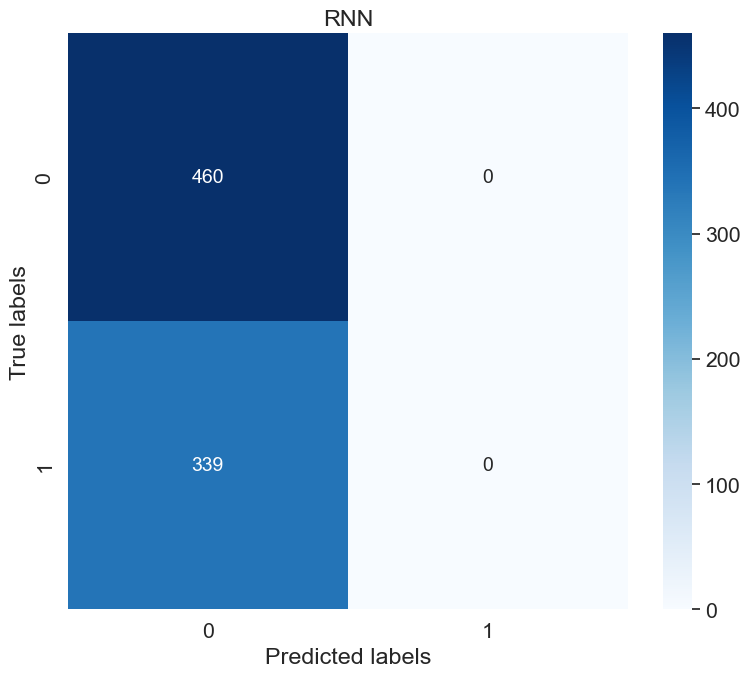

In [79]:
# @title Plot Confusion Matrix
# Collect predictions and ground truth labels
val_preds, val_targets = [], []
with torch.no_grad():  # Disable gradient computation for inference
    for xb, yb in test_loader:
        xb = xb.to(device)

        # Forward pass: get model predictions
        logits = rnn_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        val_preds.append(preds)
        val_targets.append(yb.numpy())

# Combine all batches into single arrays
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(val_targets, val_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualise confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('RNN')
plt.tight_layout()
plt.show()

### **Bidirectional Recurrent Neural Network (BiRNN)**

In [80]:
# Create model and display architecture with parameter count
rnn_model = RecurrentClassifier(
    input_size=input_shape[-1], # Pass the number of features
    hidden_size=HIDDEN_SIZE,
    num_layers=HIDDEN_LAYERS,
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    bidirectional=True,
    rnn_type='RNN'
    ).to(device)
recurrent_summary(rnn_model, input_size=input_shape)

# Set up TensorBoard logging and save model architecture
experiment_name = "bi_rnn"
x = torch.randn(1, input_shape[0], input_shape[1]).to(device)

# Define optimizer with L2 regularization
optimizer = torch.optim.AdamW(rnn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
rnn (RNN)                 [[-1, 200, 256], [4, -1, 128]] 158,208        
classifier (Linear)       [-1, 4]                      1,028          
Total params: 159,236
Trainable params: 159,236
Non-trainable params: 0
-------------------------------------------------------------------------------


In [81]:
# Load saved weights
checkpoint = torch.load('models/bi_rnn_model.pt')

# Method 1: Load all weights
rnn_model.load_state_dict(checkpoint)

<All keys matched successfully>

Accuracy over the validation set: 0.9825
Precision over the validation set: 0.9832
Recall over the validation set: 0.9825
F1 score over the validation set: 0.9825


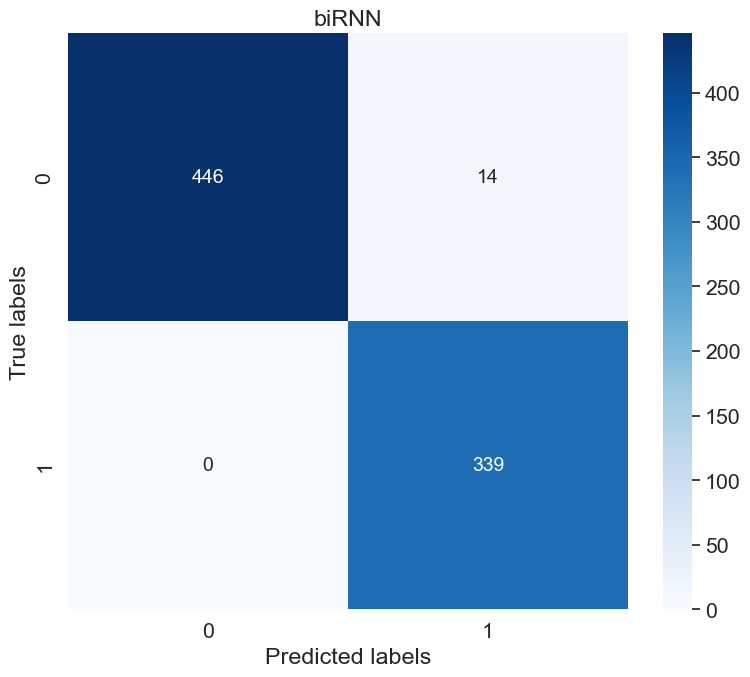

In [82]:
# @title Plot Confusion Matrix
# Collect predictions and ground truth labels
val_preds, val_targets = [], []
with torch.no_grad():  # Disable gradient computation for inference
    for xb, yb in test_loader:
        xb = xb.to(device)

        # Forward pass: get model predictions
        logits = rnn_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        val_preds.append(preds)
        val_targets.append(yb.numpy())

# Combine all batches into single arrays
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(val_targets, val_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualise confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('biRNN')
plt.tight_layout()
plt.show()

### **Long Short-Term Memory (LSTM)**

In [83]:
# Create model and display architecture with parameter count
rnn_model = RecurrentClassifier(
    input_size=input_shape[-1], # Pass the number of features
    hidden_size=HIDDEN_SIZE,
    num_layers=HIDDEN_LAYERS,
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    bidirectional=False,
    rnn_type='LSTM'
    ).to(device)
recurrent_summary(rnn_model, input_size=input_shape)

# Set up TensorBoard logging and save model architecture
experiment_name = "lstm"
x = torch.randn(1, input_shape[0], input_shape[1]).to(device)

# Define optimizer with L2 regularization
optimizer = torch.optim.AdamW(rnn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
rnn (LSTM)                [[-1, 200, 128], [2, -1, 128]] 250,880        
classifier (Linear)       [-1, 4]                      516            
Total params: 251,396
Trainable params: 251,396
Non-trainable params: 0
-------------------------------------------------------------------------------


In [84]:
# Load saved weights
checkpoint = torch.load('models/lstm_model.pt')

# Method 1: Load all weights
rnn_model.load_state_dict(checkpoint)

<All keys matched successfully>

Accuracy over the validation set: 0.5757
Precision over the validation set: 0.3315
Recall over the validation set: 0.5757
F1 score over the validation set: 0.4207


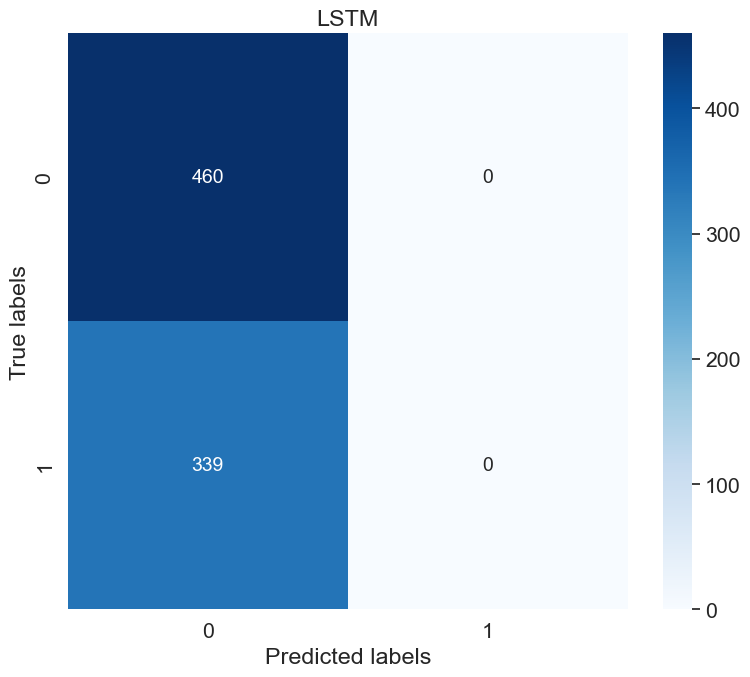

In [85]:
# @title Plot Confusion Matrix
# Collect predictions and ground truth labels
val_preds, val_targets = [], []
with torch.no_grad():  # Disable gradient computation for inference
    for xb, yb in test_loader:
        xb = xb.to(device)

        # Forward pass: get model predictions
        logits = rnn_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        val_preds.append(preds)
        val_targets.append(yb.numpy())

# Combine all batches into single arrays
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(val_targets, val_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualise confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('LSTM')
plt.tight_layout()
plt.show()

### **Bidirectional Long Short-Term Memory (BiLSTM)**

In [86]:
# Create model and display architecture with parameter count
rnn_model = RecurrentClassifier(
    input_size=input_shape[-1], # Pass the number of features
    hidden_size=HIDDEN_SIZE,
    num_layers=HIDDEN_LAYERS,
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    bidirectional=True,
    rnn_type='LSTM'
    ).to(device)
recurrent_summary(rnn_model, input_size=input_shape)

# Set up TensorBoard logging and save model architecture
experiment_name = "bi_lstm"
x = torch.randn(1, input_shape[0], input_shape[1]).to(device)

# Define optimizer with L2 regularization
optimizer = torch.optim.AdamW(rnn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
rnn (LSTM)                [[-1, 200, 256], [4, -1, 128]] 632,832        
classifier (Linear)       [-1, 4]                      1,028          
Total params: 633,860
Trainable params: 633,860
Non-trainable params: 0
-------------------------------------------------------------------------------


In [87]:
# Load saved weights
checkpoint = torch.load('models/bi_lstm_model.pt')

# Method 1: Load all weights
rnn_model.load_state_dict(checkpoint)

<All keys matched successfully>

Accuracy over the validation set: 0.9987
Precision over the validation set: 0.9988
Recall over the validation set: 0.9987
F1 score over the validation set: 0.9987


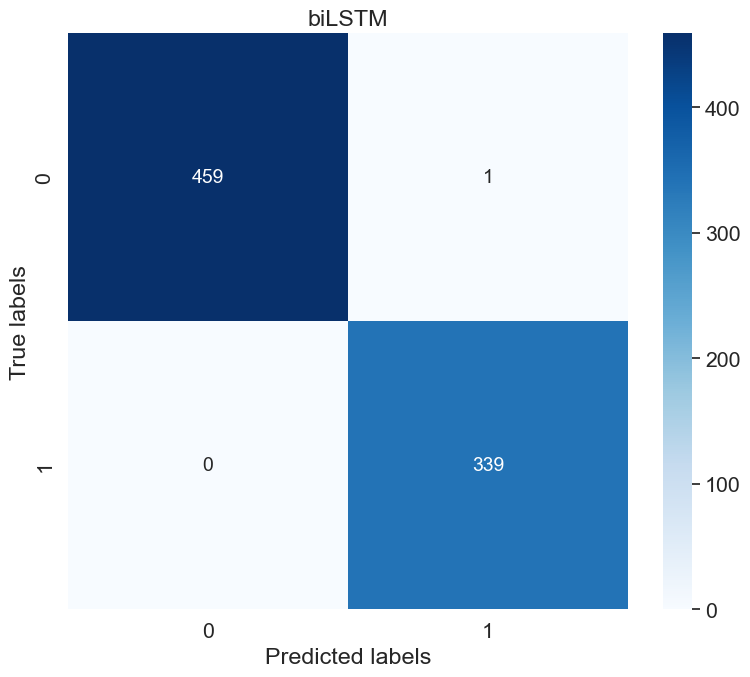

In [88]:
# @title Plot Confusion Matrix
# Collect predictions and ground truth labels
val_preds, val_targets = [], []
with torch.no_grad():  # Disable gradient computation for inference
    for xb, yb in test_loader:
        xb = xb.to(device)

        # Forward pass: get model predictions
        logits = rnn_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        val_preds.append(preds)
        val_targets.append(yb.numpy())

# Combine all batches into single arrays
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(val_targets, val_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualise confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('biLSTM')
plt.tight_layout()
plt.show()

### **Gated Recurrent Unit (GRU)**

In [89]:
# Create model and display architecture with parameter count
rnn_model = RecurrentClassifier(
    input_size=input_shape[-1], # Pass the number of features
    hidden_size=HIDDEN_SIZE,
    num_layers=HIDDEN_LAYERS,
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    bidirectional=False,
    rnn_type='GRU'
    ).to(device)
recurrent_summary(rnn_model, input_size=input_shape)

# Set up TensorBoard logging and save model architecture
experiment_name = "gru"
x = torch.randn(1, input_shape[0], input_shape[1]).to(device)

# Define optimizer with L2 regularization
optimizer = torch.optim.AdamW(rnn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
rnn (GRU)                 [[-1, 200, 128], [2, -1, 128]] 188,160        
classifier (Linear)       [-1, 4]                      516            
Total params: 188,676
Trainable params: 188,676
Non-trainable params: 0
-------------------------------------------------------------------------------


In [90]:
# Load saved weights
checkpoint = torch.load('models/gru_model.pt')

# Method 1: Load all weights
rnn_model.load_state_dict(checkpoint)

<All keys matched successfully>

Accuracy over the validation set: 0.9962
Precision over the validation set: 0.9962
Recall over the validation set: 0.9962
F1 score over the validation set: 0.9962


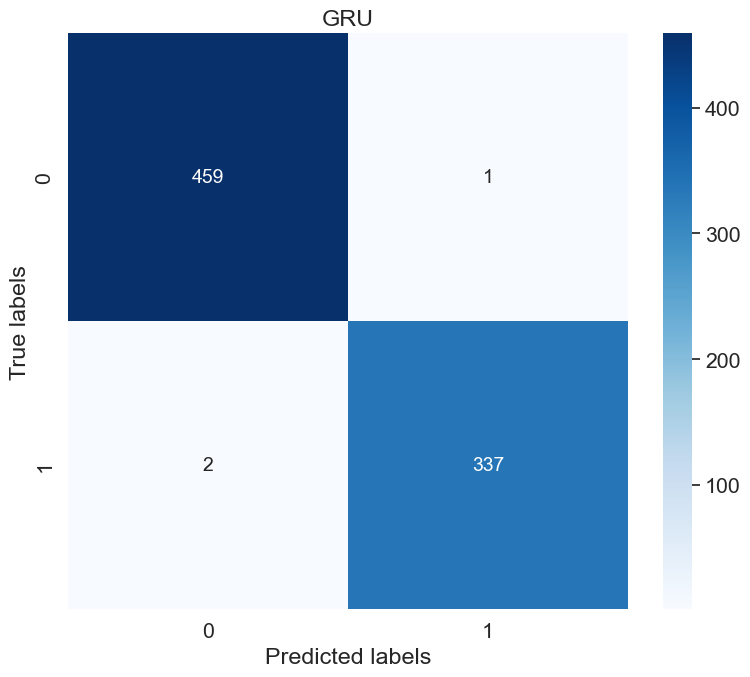

In [91]:
# @title Plot Confusion Matrix
# Collect predictions and ground truth labels
val_preds, val_targets = [], []
with torch.no_grad():  # Disable gradient computation for inference
    for xb, yb in test_loader:
        xb = xb.to(device)

        # Forward pass: get model predictions
        logits = rnn_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        val_preds.append(preds)
        val_targets.append(yb.numpy())

# Combine all batches into single arrays
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(val_targets, val_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualise confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('GRU')
plt.tight_layout()
plt.show()

### **Bidirectional Gated Recurrent Unit (BiGRU)**

In [92]:
# Create model and display architecture with parameter count
rnn_model = RecurrentClassifier(
    input_size=input_shape[-1], # Pass the number of features
    hidden_size=HIDDEN_SIZE,
    num_layers=HIDDEN_LAYERS,
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    bidirectional=True,
    rnn_type='GRU'
    ).to(device)
recurrent_summary(rnn_model, input_size=input_shape)

# Set up TensorBoard logging and save model architecture
experiment_name = "bi_gru"
x = torch.randn(1, input_shape[0], input_shape[1]).to(device)
# Define optimizer with L2 regularization
optimizer = torch.optim.AdamW(rnn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
rnn (GRU)                 [[-1, 200, 256], [4, -1, 128]] 474,624        
classifier (Linear)       [-1, 4]                      1,028          
Total params: 475,652
Trainable params: 475,652
Non-trainable params: 0
-------------------------------------------------------------------------------


In [93]:
# Load saved weights
checkpoint = torch.load('models/bi_gru_model.pt')

# Method 1: Load all weights
rnn_model.load_state_dict(checkpoint)

<All keys matched successfully>

Accuracy over the validation set: 0.9875
Precision over the validation set: 0.9878
Recall over the validation set: 0.9875
F1 score over the validation set: 0.9875


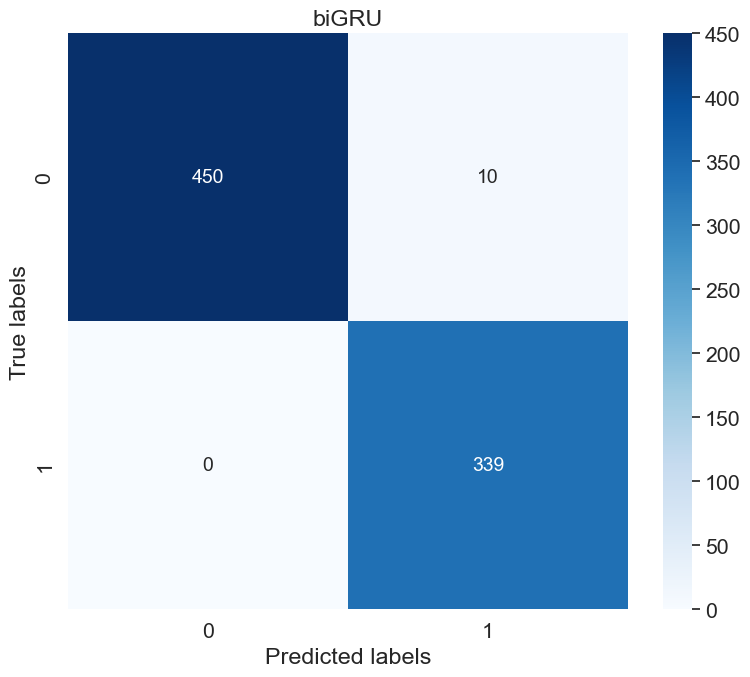

In [94]:
# @title Plot Confusion Matrix
# Collect predictions and ground truth labels
val_preds, val_targets = [], []
with torch.no_grad():  # Disable gradient computation for inference
    for xb, yb in test_loader:
        xb = xb.to(device)

        # Forward pass: get model predictions
        logits = rnn_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        val_preds.append(preds)
        val_targets.append(yb.numpy())

# Combine all batches into single arrays
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(val_targets, val_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualise confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('biGRU')
plt.tight_layout()
plt.show()